# Tumor → Healthy Counterfactual Translation
## Fine-tuned Custom Diffusion ImageToImage Results

**Paper Reference**: Custom Diffusion fine-tuning with Latent Drifting for medical image translation

This notebook visualizes:
1. Original test tumor MRI images (positive class)
2. Generated healthy/normal counterfactual images (negative class)
3. Paired image quality comparison
4. Readiness for pix2pix downstream task

In [1]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Define directories
tumor_dir = Path('./pix2pix_dataset/train_A')
healthy_dir = Path('./pix2pix_dataset/train_B')

# Load all image pairs
tumor_images = sorted([f for f in tumor_dir.glob('*.png')])
healthy_images = sorted([f for f in healthy_dir.glob('*.png')])

print(f"Tumor images: {len(tumor_images)}")
print(f"Healthy images: {len(healthy_images)}")
print(f"\nDataset ready for pix2pix: {len(tumor_images) == len(healthy_images) and len(tumor_images) > 0}")

Tumor images: 10
Healthy images: 10

Dataset ready for pix2pix: True


## 1. Side-by-Side Comparison: Tumor vs Generated Healthy

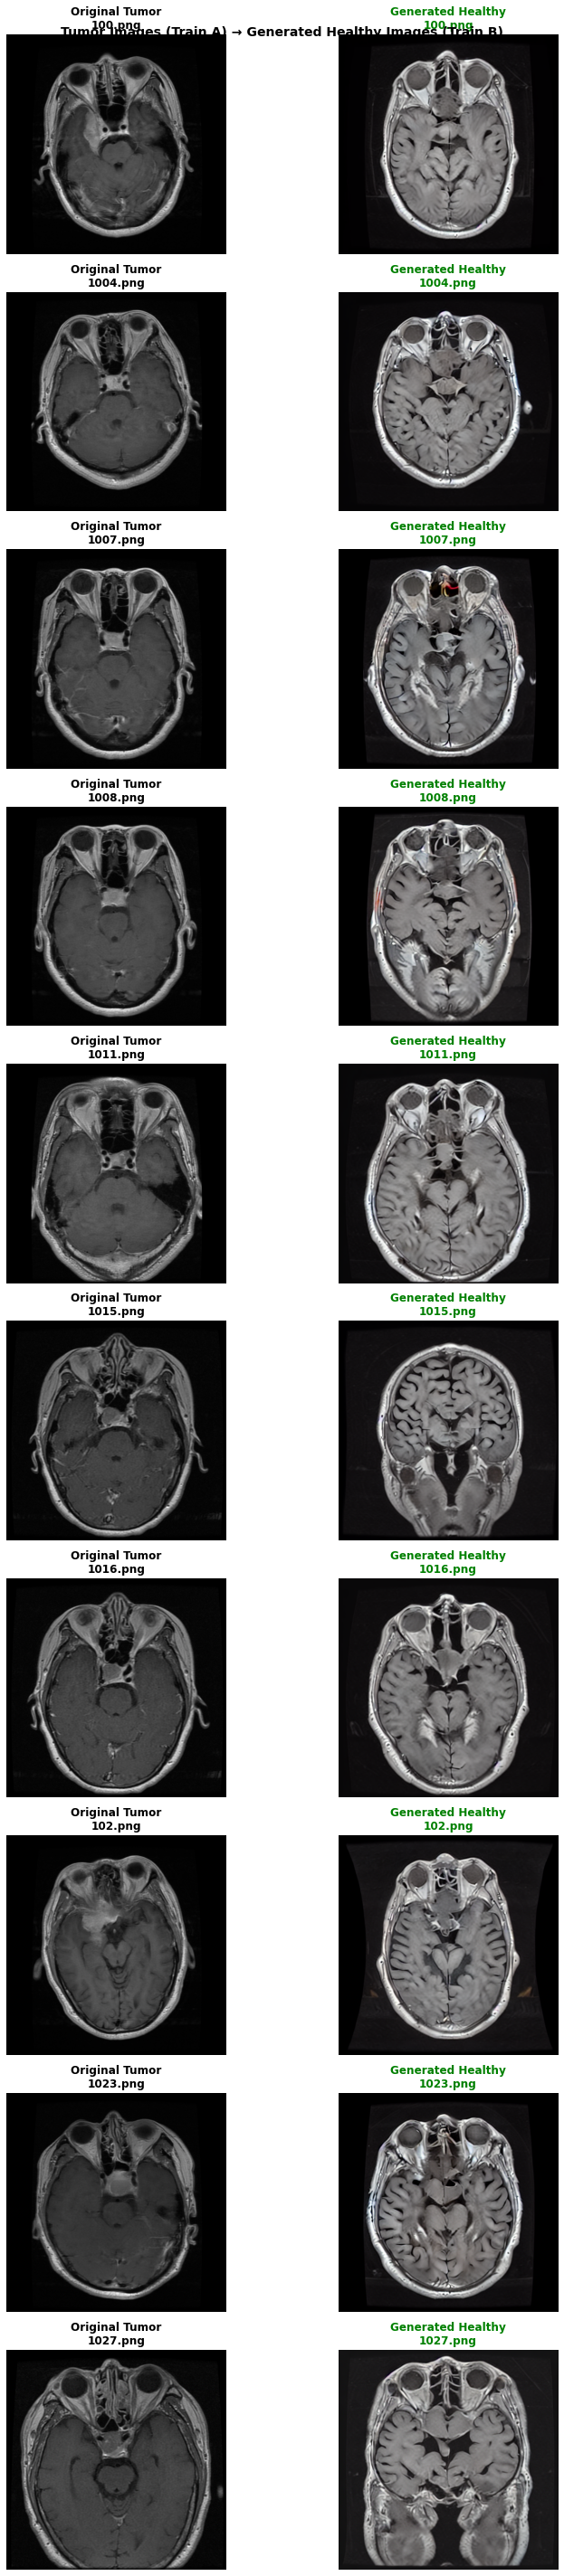


✓ Processed 10 paired images successfully


In [2]:
# Show all paired images
n_pairs = len(tumor_images)
fig, axes = plt.subplots(n_pairs, 2, figsize=(12, 4*n_pairs))
fig.suptitle('Tumor Images (Train A) → Generated Healthy Images (Train B)', 
             fontsize=14, fontweight='bold')

if n_pairs == 1:
    axes = np.array([axes])

for idx, (tumor_path, healthy_path) in enumerate(zip(tumor_images, healthy_images)):
    tumor_img = Image.open(tumor_path)
    healthy_img = Image.open(healthy_path)
    
    # Left: tumor (original)
    axes[idx, 0].imshow(tumor_img)
    axes[idx, 0].set_title(f'Original Tumor\n{tumor_path.name}', fontweight='bold')
    axes[idx, 0].axis('off')
    
    # Right: healthy (generated)
    axes[idx, 1].imshow(healthy_img)
    axes[idx, 1].set_title(f'Generated Healthy\n{healthy_path.name}', fontweight='bold', color='green')
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.show()

print(f"\n✓ Processed {len(tumor_images)} paired images successfully")

## 2. Grid View: All Generated Counterfactual Images

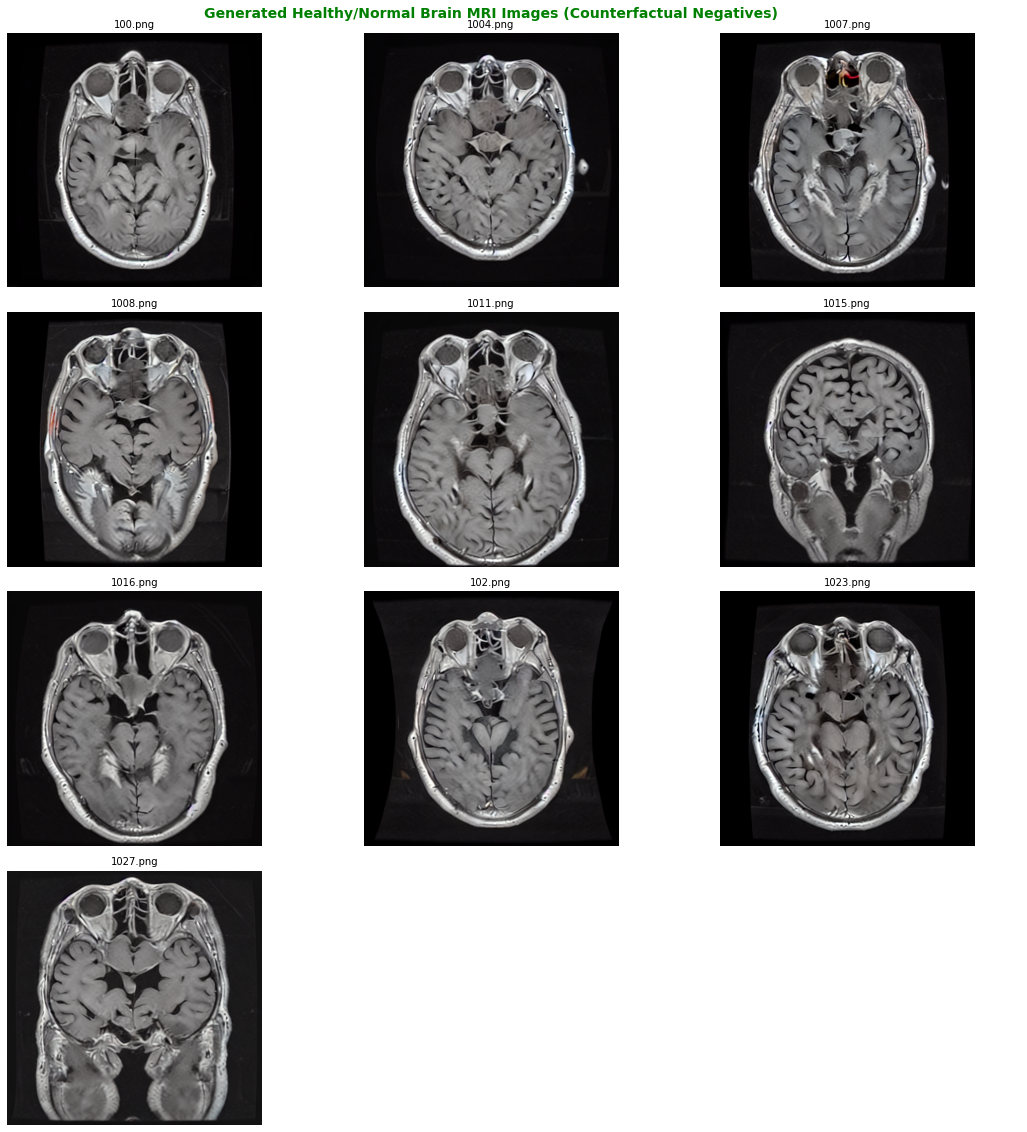

In [3]:
# Show all healthy (positive) images in grid
n_images = len(healthy_images)
n_cols = 3
n_rows = (n_images + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
fig.suptitle('Generated Healthy/Normal Brain MRI Images (Counterfactual Negatives)', 
             fontsize=14, fontweight='bold', color='green')

axes = axes.flatten()

for idx, img_path in enumerate(healthy_images):
    img = Image.open(img_path)
    axes[idx].imshow(img)
    axes[idx].set_title(f'{img_path.name}', fontsize=10)
    axes[idx].axis('off')

# Hide extra subplots
for idx in range(len(healthy_images), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 3. Dataset Summary Statistics

In [4]:
import os

# Calculate dataset statistics
tumor_sizes = [os.path.getsize(f) for f in tumor_images]
healthy_sizes = [os.path.getsize(f) for f in healthy_images]

print("="*60)
print("PIX2PIX DATASET PREPARATION SUMMARY")
print("="*60)
print(f"\nDataset Name: Custom Diffusion Fine-tuned (δ=+0.050)")
print(f"Method: ImageToImage translation (t2i) using fine-tuned UNet")
print(f"\nOriginal Test Images (Train A - Positive/Tumor):")
print(f"  Count: {len(tumor_images)} images")
print(f"  Avg size: {np.mean(tumor_sizes)/1024:.1f} KB")
print(f"  Min size: {np.min(tumor_sizes)/1024:.1f} KB")
print(f"  Max size: {np.max(tumor_sizes)/1024:.1f} KB")

print(f"\nGenerated CounterFactual Images (Train B - Negative/Healthy):")
print(f"  Count: {len(healthy_images)} images")
print(f"  Avg size: {np.mean(healthy_sizes)/1024:.1f} KB")
print(f"  Min size: {np.min(healthy_sizes)/1024:.1f} KB")
print(f"  Max size: {np.max(healthy_sizes)/1024:.1f} KB")

print(f"\nSize Ratio (Generated/Original): {np.mean(healthy_sizes)/np.mean(tumor_sizes):.2f}x")

print(f"\n" + "="*60)
print(f"✓ Ready for pix2pix downstream task")
print(f"  Location: ./pix2pix_dataset/")
print(f"  Total pairs: {len(tumor_images)}")
print(f"  Split recommendation: 8 train, 2 test")
print("="*60)

PIX2PIX DATASET PREPARATION SUMMARY

Dataset Name: Custom Diffusion Fine-tuned (δ=+0.050)
Method: ImageToImage translation (t2i) using fine-tuned UNet

Original Test Images (Train A - Positive/Tumor):
  Count: 10 images
  Avg size: 142.1 KB
  Min size: 120.4 KB
  Max size: 171.8 KB

Generated CounterFactual Images (Train B - Negative/Healthy):
  Count: 10 images
  Avg size: 298.3 KB
  Min size: 275.5 KB
  Max size: 340.2 KB

Size Ratio (Generated/Original): 2.10x

✓ Ready for pix2pix downstream task
  Location: ./pix2pix_dataset/
  Total pairs: 10
  Split recommendation: 8 train, 2 test


## 4. Image Intensity Distribution Analysis

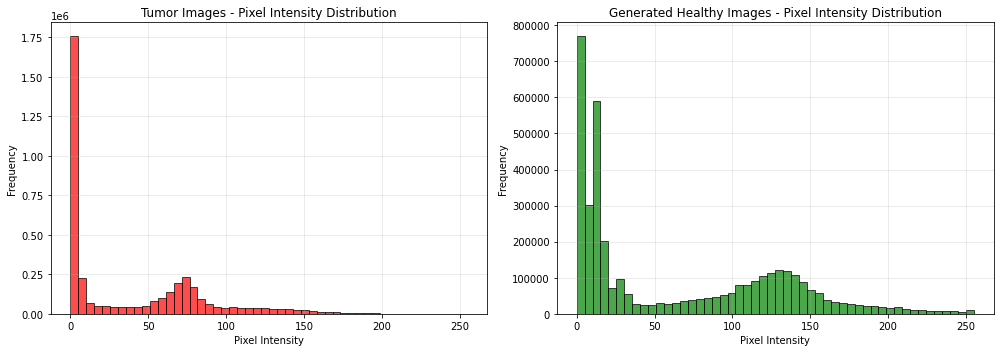


Pixel Intensity Statistics:
Tumor images - Mean: 39.2, Std: 45.7
Healthy images - Mean: 64.3, Std: 65.2


In [5]:
# Compare pixel intensity distributions
tumor_pixels = []
healthy_pixels = []

for tumor_path, healthy_path in zip(tumor_images[:5], healthy_images[:5]):
    tumor_img = np.array(Image.open(tumor_path))
    healthy_img = np.array(Image.open(healthy_path))
    
    tumor_pixels.extend(tumor_img.flatten())
    healthy_pixels.extend(healthy_img.flatten())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram for tumor images
axes[0].hist(tumor_pixels, bins=50, alpha=0.7, color='red', edgecolor='black')
axes[0].set_xlabel('Pixel Intensity')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Tumor Images - Pixel Intensity Distribution')
axes[0].grid(alpha=0.3)

# Histogram for healthy images  
axes[1].hist(healthy_pixels, bins=50, alpha=0.7, color='green', edgecolor='black')
axes[1].set_xlabel('Pixel Intensity')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Generated Healthy Images - Pixel Intensity Distribution')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPixel Intensity Statistics:")
print(f"Tumor images - Mean: {np.mean(tumor_pixels):.1f}, Std: {np.std(tumor_pixels):.1f}")
print(f"Healthy images - Mean: {np.mean(healthy_pixels):.1f}, Std: {np.std(healthy_pixels):.1f}")

## 5. Next Steps: Pix2Pix Training

### Dataset is ready for pix2pix fine-tuning:

```bash
# Pix2pix training command:
python -m pix2pix.train \
  --dataroot ./pix2pix_dataset \
  --name tumor_to_healthy \
  --model pix2pix \
  --direction BtoA \
  --lambda_L1 100 \
  --niter 100 \
  --niter_decay 100 \
  --batch_size 2
```

### Expected Results:
- Train A (Tumor images): Input to pix2pix generator
- Train B (Generated Healthy): Target output for discriminator
- Pix2pix learns tumor→healthy translation
- Can be used for medical image synthesis or data augmentation